# Post-Training Quantization
## PyTorch -> TfLite

In [1]:
import os
import torch

from model_compression.src.utils import load_data, process_callbacks
from model_compression.src.converters.to_tflite import convert_pytorch_model_to_tflite
from model_compression.src.train.knowledge_distillation import train_kd
from model_compression.src.utils.logging_setup import configure_logging
from model_compression.src.quantization.core.quantize import post_training_quantization_pytorch_model, post_training_quantization_pytorch_model_tflite, post_training_quantization_pytorch_model_tflite_legacy

2025-05-01 19:07:05.173112: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-01 19:07:05.180929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746140825.189796   23777 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746140825.192471   23777 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746140825.199985   23777 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Hyperparameters

[INFO 2025-05-01 19:07:13,845 preprocessing.py:44] Train size: 29322
[INFO 2025-05-01 19:07:13,846 preprocessing.py:47]   Class 'Actinic keratoses': 693 samples
[INFO 2025-05-01 19:07:13,846 preprocessing.py:47]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-05-01 19:07:13,846 preprocessing.py:47]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-05-01 19:07:13,847 preprocessing.py:47]   Class 'Chickenpox': 900 samples
[INFO 2025-05-01 19:07:13,847 preprocessing.py:47]   Class 'Cowpox': 792 samples
[INFO 2025-05-01 19:07:13,847 preprocessing.py:47]   Class 'Dermatofibroma': 191 samples
[INFO 2025-05-01 19:07:13,847 preprocessing.py:47]   Class 'HFMD': 1932 samples
[INFO 2025-05-01 19:07:13,847 preprocessing.py:47]   Class 'Healthy': 1368 samples
[INFO 2025-05-01 19:07:13,847 preprocessing.py:47]   Class 'Measles': 660 samples
[INFO 2025-05-01 19:07:13,848 preprocessing.py:47]   Class 'Melanocytic nevi': 10300 samples
[INFO 2025-05-01 19:07:13,848 preprocessing.p

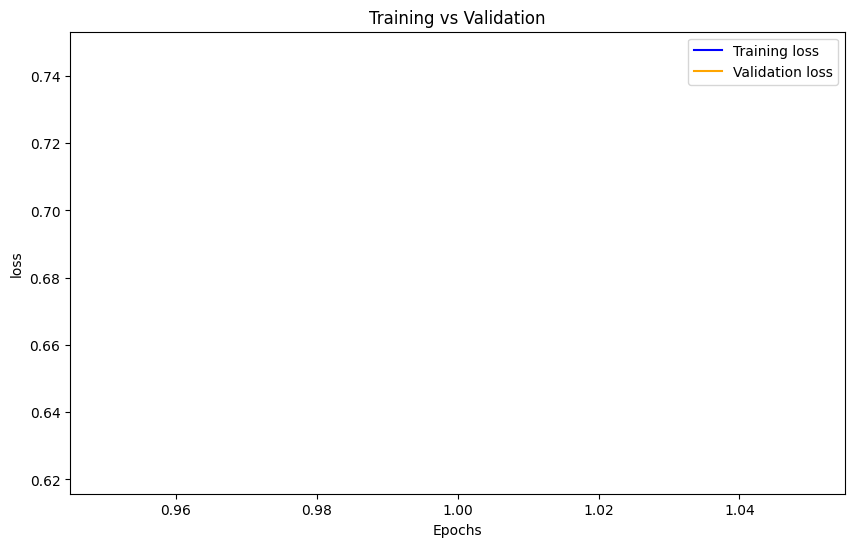

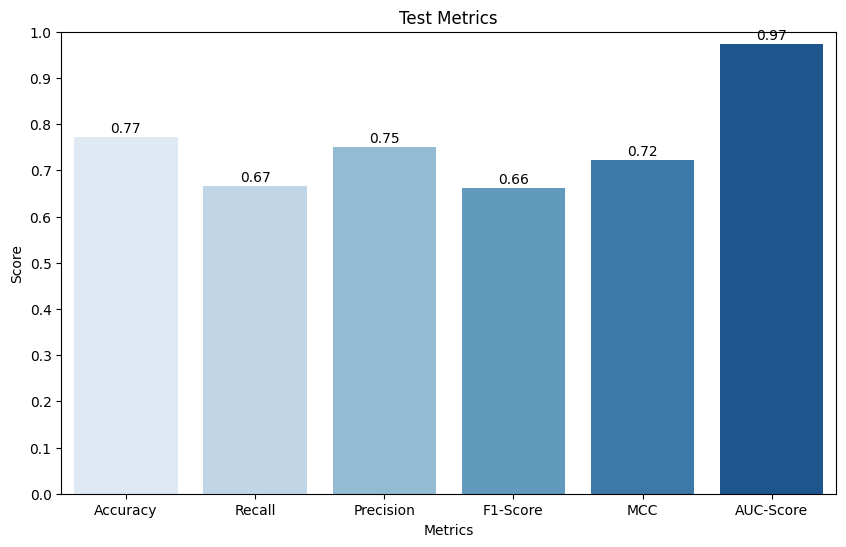

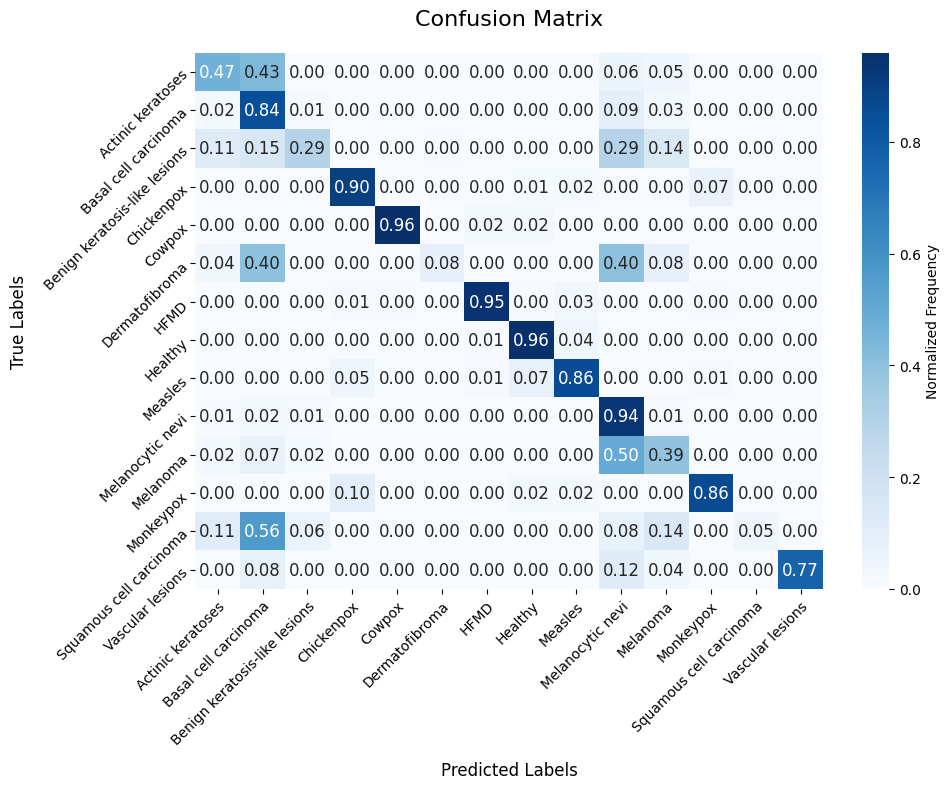

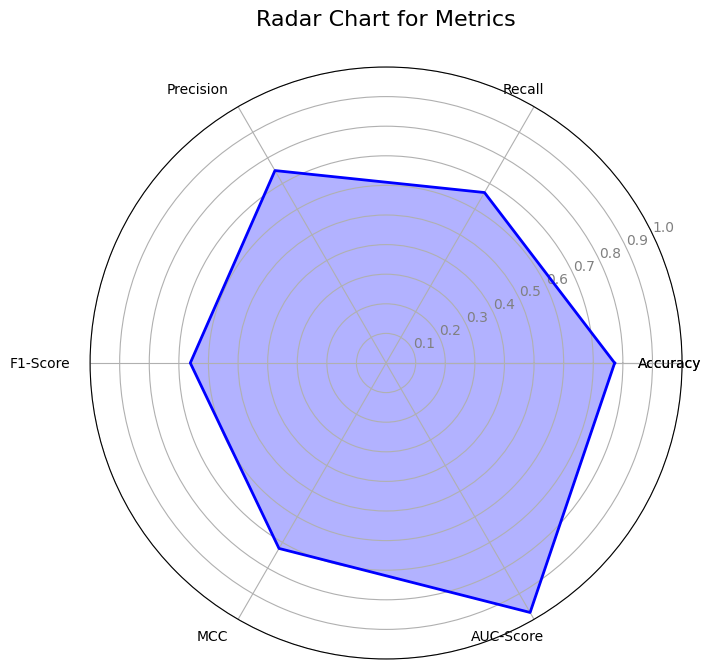

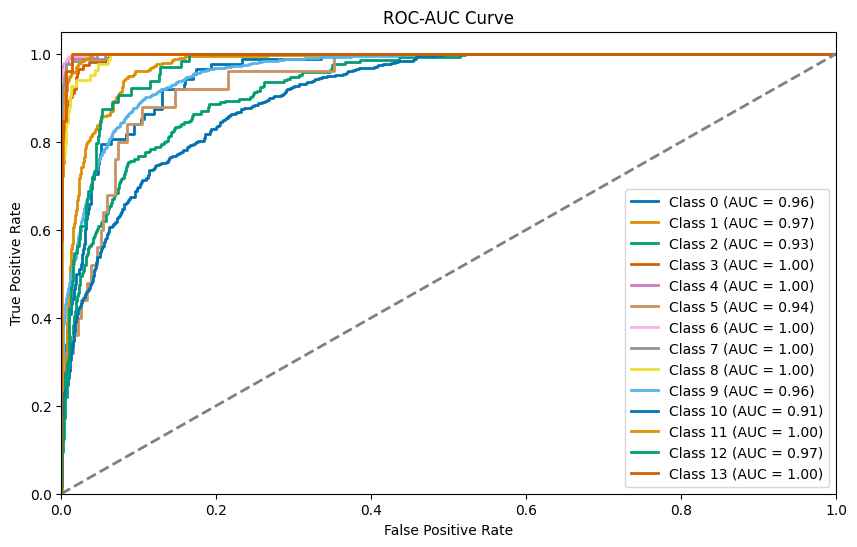

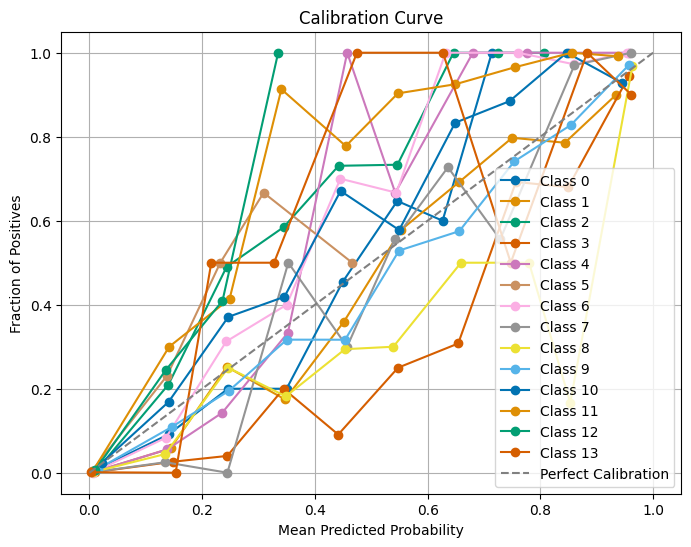

In [3]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/KD"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset_name=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, student = train_kd(
                        teacher_name=teacher_model, 
                        student_name=student_model,
                        data_loaders=dataloaders,
                        save_dir=save_dir,
                        learning_rate=learning_rate,
                        num_epochs=epochs,
                        criterion_name = criterion,
                        optimizer_name = optimizer,
                        callbacks=CALLBACKS,
                        quant_mode=None,
                        teacher_weights_path=teacher_model_weights,
                        device=device,
                )


### 2. Post-training Quantization

In [5]:

example_inputs = next(iter(dataloaders['train']))[0].to("cpu")
post_training_quantization_pytorch_model(student.to("cpu"), (example_inputs,), save_path="test1.tflite")

W0501 19:10:57.615000 23777 site-packages/torch/_export/__init__.py:67] +============================+
W0501 19:10:57.616000 23777 site-packages/torch/_export/__init__.py:68] |     !!!   WARNING   !!!    |
W0501 19:10:57.616000 23777 site-packages/torch/_export/__init__.py:69] +============================+
W0501 19:10:57.616000 23777 site-packages/torch/_export/__init__.py:70] capture_pre_autograd_graph() is deprecated and doesn't provide any function guarantee moving forward.
W0501 19:10:57.617000 23777 site-packages/torch/_export/__init__.py:71] Please switch to use torch.export.export_for_training instead.
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/torch/fx/graph.py:1199: UserWarning: erase_node(_native_batch_norm_legit_no_training) on an already erased node
  warnings.warn(f"erase_node({to_erase}) on an already erased node")
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/torch/fx/graph.py:1199: UserWarning: erase_node(_native_batch_nor

INFO:tensorflow:Assets written to: /tmp/tmpnv6w9a1e/assets


[INFO 2025-05-01 19:11:09,238 builder_impl.py:836] Assets written to: /tmp/tmpnv6w9a1e/assets
W0000 00:00:1746141072.619205   23777 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746141072.619228   23777 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-01 19:11:12.619574: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnv6w9a1e
2025-05-01 19:11:12.621155: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-01 19:11:12.621160: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpnv6w9a1e
I0000 00:00:1746141072.637272   23777 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-05-01 19:11:12.639623: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-01 19:11:12.773817: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/

In [7]:

example_inputs = next(iter(dataloaders['train']))[0].to("cpu")

post_training_quantization_pytorch_model_tflite(student.to("cpu"), (example_inputs,), recipe="full_int8_dynamic", save_path="test2.tflite")

[INFO 2025-05-01 19:11:50,577 _jax_lowerings.py:32] Use JAX lowering: aten.sub.Tensor
[INFO 2025-05-01 19:11:50,586 _jax_lowerings.py:32] Use JAX lowering: aten.sqrt
[INFO 2025-05-01 19:11:50,588 _jax_lowerings.py:32] Use JAX lowering: aten.div


INFO:tensorflow:Assets written to: /tmp/tmpvq8qg78i/assets


[INFO 2025-05-01 19:11:54,230 builder_impl.py:836] Assets written to: /tmp/tmpvq8qg78i/assets
W0000 00:00:1746141119.025121   23777 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746141119.025142   23777 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-01 19:11:59.025272: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvq8qg78i
2025-05-01 19:11:59.027496: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-01 19:11:59.027501: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpvq8qg78i
2025-05-01 19:11:59.052017: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-01 19:11:59.239467: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpvq8qg78i
2025-05-01 19:11:59.283922: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve 

In [8]:
example_inputs = next(iter(dataloaders['train']))[0].to("cpu")
post_training_quantization_pytorch_model_tflite_legacy(student.to("cpu"), (example_inputs,), dataloaders['test'], save_path="test3.tflite")

INFO:tensorflow:Assets written to: /tmp/tmp6voph1yi/assets


[INFO 2025-05-01 19:12:12,996 builder_impl.py:836] Assets written to: /tmp/tmp6voph1yi/assets
W0000 00:00:1746141137.408692   23777 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746141137.408714   23777 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-01 19:12:17.408844: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp6voph1yi
2025-05-01 19:12:17.410905: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-01 19:12:17.410911: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp6voph1yi
2025-05-01 19:12:17.435736: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-01 19:12:17.626557: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp6voph1yi
2025-05-01 19:12:17.672016: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve 

### 3. Export to TfLite

In [ ]:
example_inputs = next(iter(dataloaders['train']))[0].to(device)
tflite_path = os.path.join(save_dir, f"{student_model}_kd.tflite")
convert_pytorch_model_to_tflite(student, (example_inputs,), tflite_path)

### 4. Model Sizes

In [ ]:
print("qat:", os.path.getsize("models/SkinCancer/KD/mobilenet_v2_qat_kd.pth") / 1e6)
print("tflite:", os.path.getsize("models/SkinCancer/KD/mobilenet_v2_kd.tflite") / 1e6)